In [1]:
import numpy as np
print(np.__version__)

2.4.6


In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [9]:
import joblib

pipeline = joblib.load("best_xgb_pipeline.pkl")
preprocessor = pipeline.named_steps["preprocessor"]
xgb_model = pipeline.named_steps["classifier"]

In [11]:
X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

In [12]:
X_test_processed = preprocessor.transform(X_test)

In [13]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__amount' 'num__oldbalanceOrg' 'num__newbalanceOrig'
 'num__oldbalanceDest' 'num__newbalanceDest' 'cat__type_CASH_OUT'
 'cat__type_DEBIT' 'cat__type_PAYMENT' 'cat__type_TRANSFER']


In [26]:
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in preprocessor.get_feature_names_out()
]

X_sample = preprocessor.transform(X_test[:1000])

X_sample_df = pd.DataFrame(
    X_sample,
    columns=feature_names
)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_sample_df)

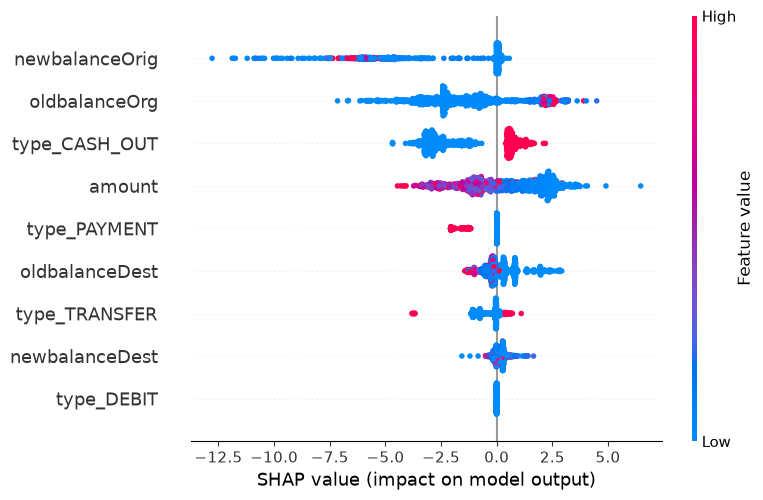

In [27]:
shap.summary_plot(
    shap_values.values,
    X_sample,
    feature_names=feature_names
)

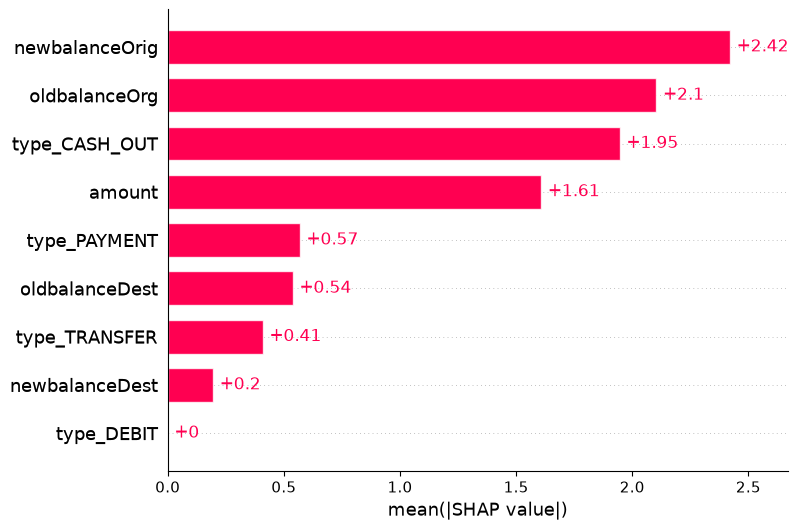

In [28]:
shap.plots.bar(shap_values)

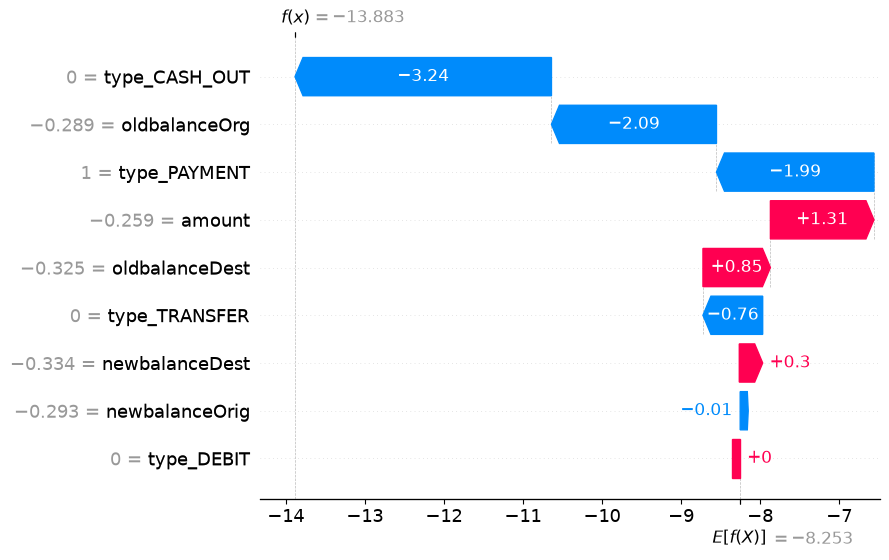

In [29]:
sample_index = 5

shap.plots.waterfall(shap_values[sample_index])